# Challenge 15 - Euler's Method

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Inference: I believe that as the step size becomes larger, the error of each point and total error will become larger and larger. I mainly believe this because each euler straight line step is longer and longer, therefore less accurate for a non-linear curve. I also believe we shouldn't trust the step size once it is > 0.5 for this range of 0 through 2.


 Step Size:  0.01

 Point Error [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]

 Total Error 0.0

 Step Size:  0.06

 Point Error [0.         0.00584238 0.01031672 0.01366333 0.01608498 0.0177524
 0.01880904 0.01937507 0.0195509  0.01942014 0.01905217 0.01850433
 0.01782377 0.01704909 0.01621163 0.01533672 0.01444459 0.01355127
 0.01266925 0.01180812 0.01097508 0.01017534 0.00941252 0.00868893
 0.00800583 0.00736366 0.00676218 0.

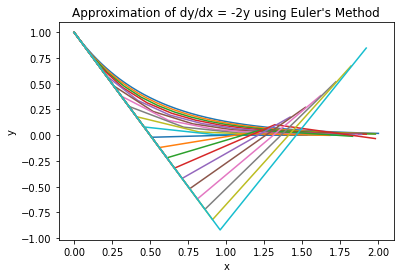

In [2]:
# Define parameters

first_y = None
first_x = None

for h in np.arange(0.01, 1.0, 0.05):
        
        
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_start + h*num_steps, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1
    
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    # storing the first run as a reference
    if first_y is None:
        first_y = y_values.copy()
        first_x = x_values.copy()

    # error(current run vs first run)
    first_interp = np.interp(x_values, first_x, first_y)

    perr = np.abs(y_values - first_interp)  # pointwise error vs first run
    tot_err = np.sum(perr)  # total accumulated error
    
    # Printing the results (Current step size, Error for each point, and the total error)
    print("\n Step Size: ", round(h,3))
    print("\n Point Error", perr) 
    print("\n Total Error", tot_err)
    
    # Plotting the results
    plt.plot(x_values, y_values, label="Euler's Method Approximation")

    
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.show()

Conclusion: My inference was correct, as increasing the step size leads to larger error in the Euler approximation. This matches my idea that larger step sizes produce a poorer approximation of the curve. The growth in error is especially visible in both the step-to-step variation and deviation between different runs. In this case, the approximation becomes very inaccurate around h = 0.3 – 0.4, and for larger step sizes such as h>0.5, the solution becomes increasingly less reliable for representing the actual exponential decay.